# IDS Challenge: Sub-Projekt 01 Optimization
## Results 

### Group: Seahorses
### Tutor: ___

This is your workspace - implement all submission-relevant functions and elements here and add short text-descriptions that explain your steps. (See `README_EN.ipynb`)

---

Set up imports

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ortools.constraint_solver import pywrapcp, routing_enums_pb2

This cell imports the data from the modified files and the time matrix needed for the CVRP solver

In [10]:
times = pd.read_csv("data/ls_matrix_55_42.csv", sep='; ', engine="python") #read data from LSM into a DataFrame

n = 55 #number of machines
time_matrix = np.zeros((n, n)) #create a 55 by 55 time matrix

for row in times.itertuples(index=False): #populate time matrix
    i = int(row.start)
    j = int(row.end)
    time_matrix[i][j] = row.ls

np.savetxt("data/timematrix.csv", time_matrix, delimiter=", ") #debug

coords = pd.read_csv("data/allpoint.csv", sep="; ", engine="python") #read the machine coordinate data into a dataframe
coords.columns = ["machine", "x", "y", "floor"]
coords = coords.set_index("machine") #set index for DataFrame
depot = 0 #depot is at the first index

This cell sets up the "penalty" for skipping a machine, see explanation in the inline comments.

In [11]:
penalty = np.zeros(n)
#the penalty is basically how much it costs to skip a machine
#it is a list because the penalty is always equal to the time it takes to go from the depot to the machine and back
#like so:
# depot -> machine -> depot
#that's why it can be a list and not a matrix, because the start and end is the same

for i in range(n):
    if i == depot:
        continue
    penalty[i] = 2 * (time_matrix[depot][i] + time_matrix[i][depot])
    #I added the times 2 just to see how it works

np.savetxt("data/penalty.csv", penalty, delimiter=", ") #debug

In [12]:
manager = pywrapcp.RoutingIndexManager(n, 3, depot)
routing = pywrapcp.RoutingModel(manager) #setting up the ortools routing according to the guide

In [13]:
def time_callback(from_index, to_index): #this is the function that tells the solver how much it takes to go from one machine to the next
    i = manager.IndexToNode(from_index)  #for this case it is also the "capacity" constraint
    j = manager.IndexToNode(to_index)
    return int(time_matrix[i][j]) #see time_matrix

time_callback_index = routing.RegisterTransitCallback(time_callback)
routing.SetArcCostEvaluatorOfAllVehicles(time_callback_index)

In [14]:
routing.AddDimension(       #dimensions are what keeps track of the total distance the vehicle travels, and in this case the
    time_callback_index,    #capacity constraint to be solved around is also the total distance it can travel
    0,
    18000,   #5 hours in seconds
    True,
    "Time"
)

True

In [15]:
for node in range(n):
    if node == depot:
        continue
    routing.AddDisjunction(             #this is how the solver knows the penalty for skipping a machine and
        [manager.NodeToIndex(node)],    #decides whether to skip it or not
        int(penalty[node])
    )

In [16]:
search_parameters = pywrapcp.DefaultRoutingSearchParameters() #create the search parameters
search_parameters.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC #solution strategy
search_parameters.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
search_parameters.time_limit.seconds = 30 #time limit for solving

assignment = routing.SolveWithParameters(search_parameters)

In [17]:
routes = []
visited = set()
for vehicle in range(3):
    index = routing.Start(vehicle)
    route = []

    while not routing.IsEnd(index):
        node = manager.IndexToNode(index)
        route.append(node)
        visited.add(node)
        index = assignment.Value(routing.NextVar(index))

    route.append(depot)
    routes.append(route)
visited.add(depot)
all_nodes = set(range(n))
skipped = all_nodes - visited
human_time = 0
for node in skipped:
    human_time+=penalty[node]

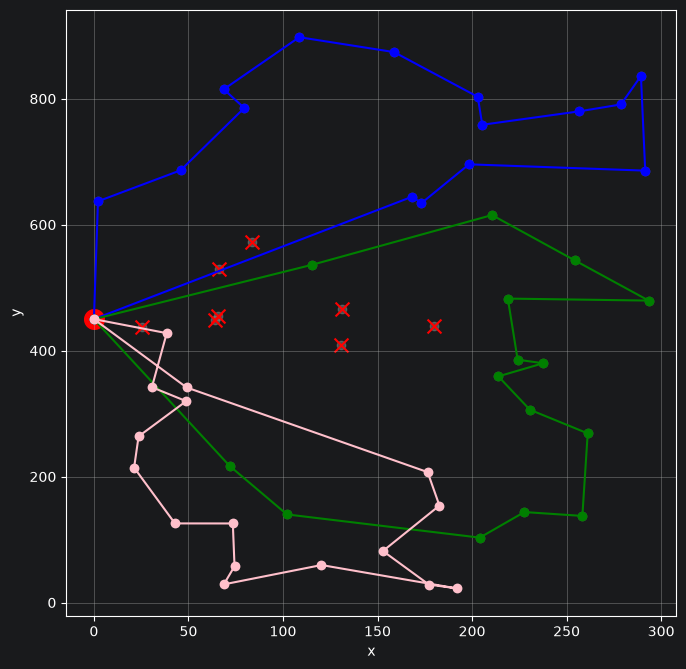

In [42]:
plt.figure(figsize=(20, 20, "cm"))



plt.scatter(
    coords["x"],
    coords["y"],
    c="gray",
    alpha=0.5,
    label="machines"
)

plt.scatter(
    coords.loc[0, "x"],
    coords.loc[0, "y"],
    c="red",
    s=200,
    label="depot"
)

plt.scatter(
    coords.loc[list(skipped), "x"],
    coords.loc[list(skipped), "y"],
    color="red",
    marker="x",
    s=100,
    label="Skipped"
)

colors = ["blue", "green", "pink"]

for r_idx, route in enumerate(routes):
    xs = [coords.loc[i, "x"] for i in route]
    ys = [coords.loc[i, "y"] for i in route]
    plt.plot(xs, ys, marker="o", color=colors[r_idx])

plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

In [19]:
def calc_total_tour_time(sequ, matrix):
    total_time = 0
    for i in range(len(sequ)-1):
        total_time += matrix.loc[
            (matrix["start"] == sequ[i]) &
            (matrix["end"] == sequ[i+1]),
            "ls"
        ].iloc[0]
    return total_time

In [20]:
count = 1
for i in routes:
    tour_time_sec = calc_total_tour_time(i, times)
    print(f"Total time for tour {count}: {tour_time_sec} seconds")
    print(f"Total time for tour {count}: {tour_time_sec/60} minutes")
    print(f"Total time for tour {count}: {tour_time_sec/3600} hours")
    print()
    count+=1

print(f"Machines skipped: {len(skipped)}")
print(f"Human inspection time: {human_time:.1f} seconds")
print(f"Human inspection time: {human_time/60:.1f} minutes")
print(f"Human inspection time: {human_time/3600:.2f} hours")

Total time for tour 1: 17716.21623037343 seconds
Total time for tour 1: 295.2702705062238 minutes
Total time for tour 1: 4.921171175103731 hours

Total time for tour 2: 17826.001160672226 seconds
Total time for tour 2: 297.1000193445371 minutes
Total time for tour 2: 4.951666989075618 hours

Total time for tour 3: 17964.30982079231 seconds
Total time for tour 3: 299.40516367987186 minutes
Total time for tour 3: 4.990086061331198 hours

Machines skipped: 8
Human inspection time: 36571.1 seconds
Human inspection time: 609.5 minutes
Human inspection time: 10.16 hours
